In [1]:
# Imports

import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import pandas as pd

# load in the results
result_dir = "/Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/"

date = "2026-03-12/"
slurm_job = 16316301

result_dir = result_dir + date + str(slurm_job) + "/"

runs = [0]
batches = [5, 7, 9, 14]

# start at line number 1
def read_ith_line(i, filename):
    with open(filename, "r") as file:
        for line_number, line in enumerate(file, start=1):
            if (line_number == i):
                return [float(x) for x in line.strip().split()]
            
    # If file exists but doesn't have that many lines
    return []

# Part 4 - With the delay

/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_47676/2621980306.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_47676/2621980306.py:80: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


[26.0, 39.0, 52.0, 26.0]
[28.0, 43.0, 58.0, 28.0]
[30.0, 47.0, 64.0, 30.0]
[28.0, 41.0, 54.0, 28.0]
[30.0, 45.0, 60.0, 30.0]
[32.0, 49.0, 66.0, 32.0]
[30.0, 43.0, 56.0, 30.0]
[32.0, 47.0, 62.0, 32.0]
[34.0, 51.0, 68.0, 34.0]


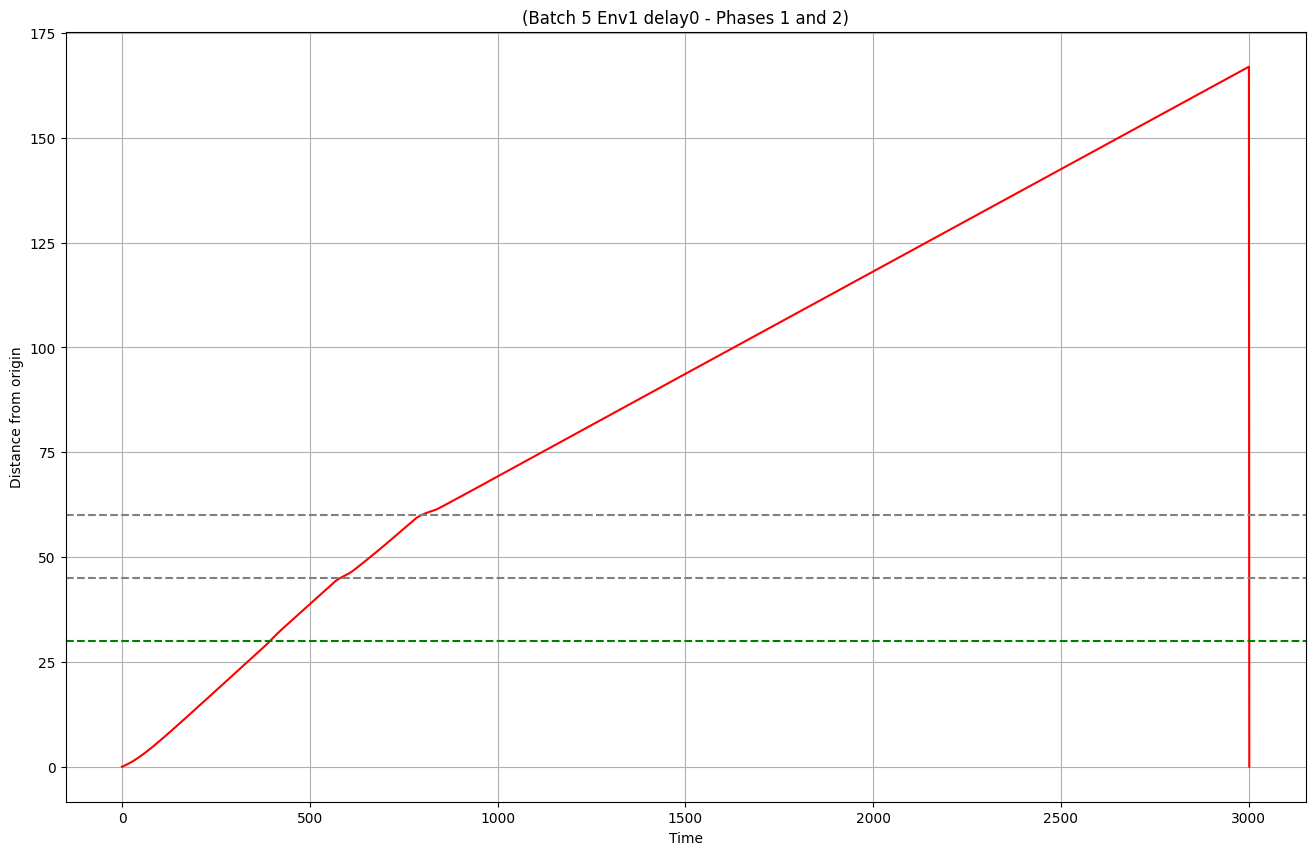

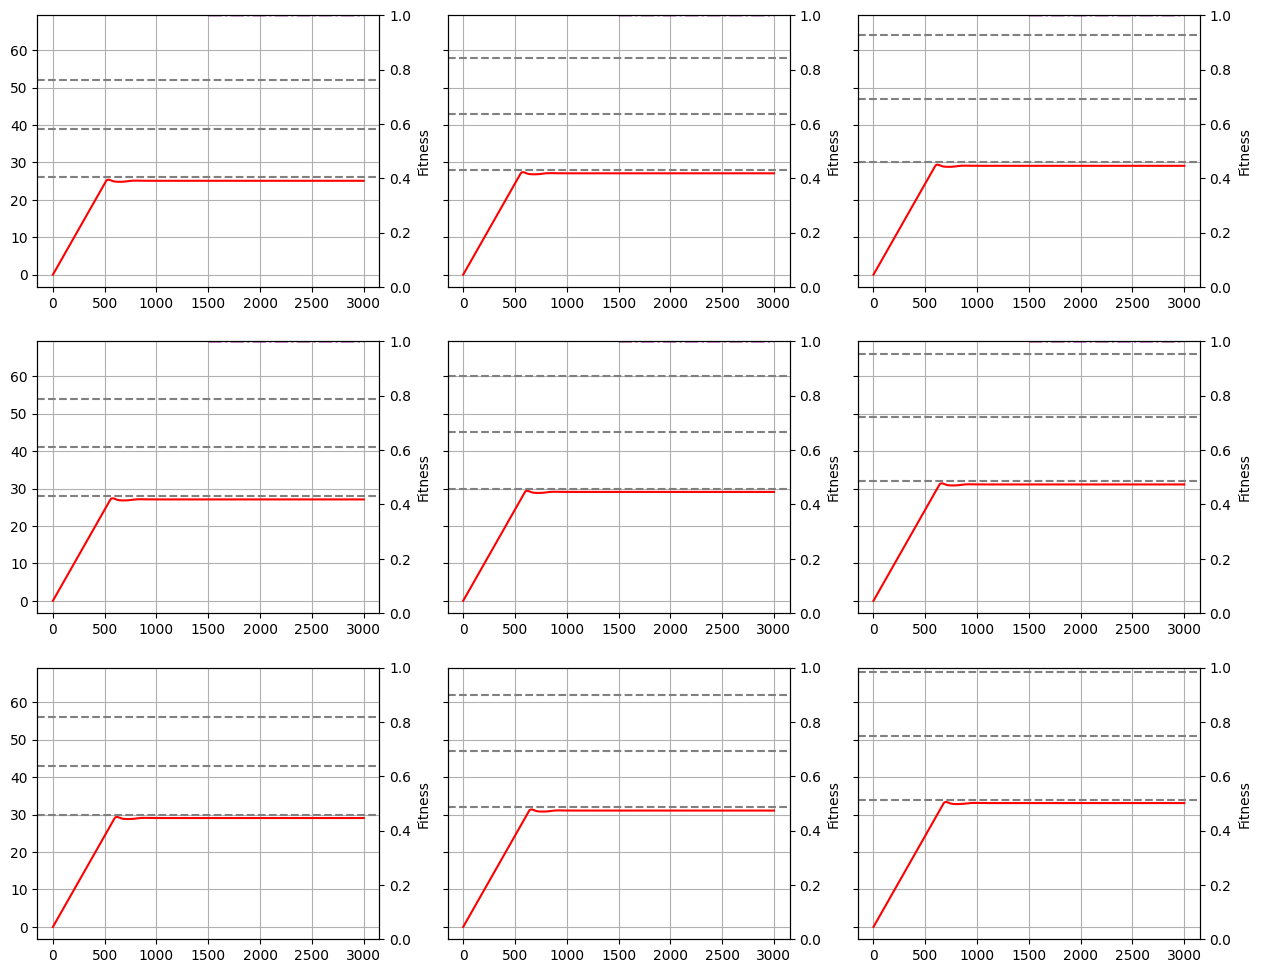

In [ ]:
# the plot for a single run, batch and env with only one delay
batch = batches[0]
delay = "delay0"
stage = "stage4"
run=0

env_behaviour="Env1"
env_other="env1"
env_index = 1
env_index=0
fig, ax = plt.subplots(figsize=(16,10))
# first plot phase 1 and phase 2 in the same plot
phase1_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_{env_behaviour}_{delay}_{stage}_Phase1.dat"
phase2_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_{env_behaviour}_{delay}_{stage}_Phase2.dat"
combined = []
combined.extend(read_ith_line(1, phase1_dir))
combined.extend(read_ith_line(1, phase2_dir))
x = list(range(0, len(combined)))
ax.plot(x, combined, label=f"Agent", color="red")

landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_{run}_{env_other}_{delay}_{stage}_phase2.dat"
landmark = read_ith_line(1, landmark_file)
food = landmark[3]
landmarks = [0,1,2]
for i in landmarks:
    if (landmark[i] != food):
        ax.axhline(y=landmark[i], linestyle="--", label=f"Landmark {i}", color="grey")
ax.axhline(y=food, linestyle="--", label="Food Position", color="green")

# plot it
ax.set_xlabel("Time")
ax.set_ylabel("Distance from origin")
ax.set_title(f"(Batch {batch} {env_behaviour} {delay} - Phases 1 and 2)")
ax.grid(True)
fig.show()


# then plot phase 3 in a 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(15,12), sharey=True)

phase3_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_{env_behaviour}_{delay}_{stage}_Phase3.dat"
landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_{run}_{env_other}_{delay}_{stage}_phase3.dat"
fitness_file = result_dir+ f"batch_{batch}/run_{run}/fitness_{run}_{env_other}_{delay}_{stage}_phase1.dat"

counter = 1
for x in range(0, 3):
    for y in range(0,3):
        ax = axes[x, y]
        ax2 = ax.twinx()
        
        # the behaviour
        behaviour = read_ith_line(counter, phase3_dir)
        behaviour_x = list(range(0, len(behaviour)))
        ax.plot(behaviour_x, behaviour, label=f"Agent", color="red")

        # the landmark
        landmark = read_ith_line(counter, landmark_file)
        food = landmark[3]
        landmarks = [0,1,2]
        for i in landmarks:
            if (i != env_index-1):
                ax.axhline(y=landmark[i], linestyle="--", label=f"Landmark {i}", color="grey")
            else:
                ax.axhline(y=landmark[i], linestyle="--", label="Food Position", color="green")

        # fitness
        fitness = read_ith_line(counter, fitness_file)
        fitness_start = (len(behaviour) - len(fitness))
        fitness_x = range(fitness_start, len(fitness)+fitness_start)

        ax2.plot(fitness_x, fitness, linestyle="dashdot", color="purple")

        counter += 1

        ax2.set_ylim(bottom=0, top=1)
        ax2.set_ylabel("Fitness")
        ax.grid(True)
ax.set_title(f"")
fig.show()


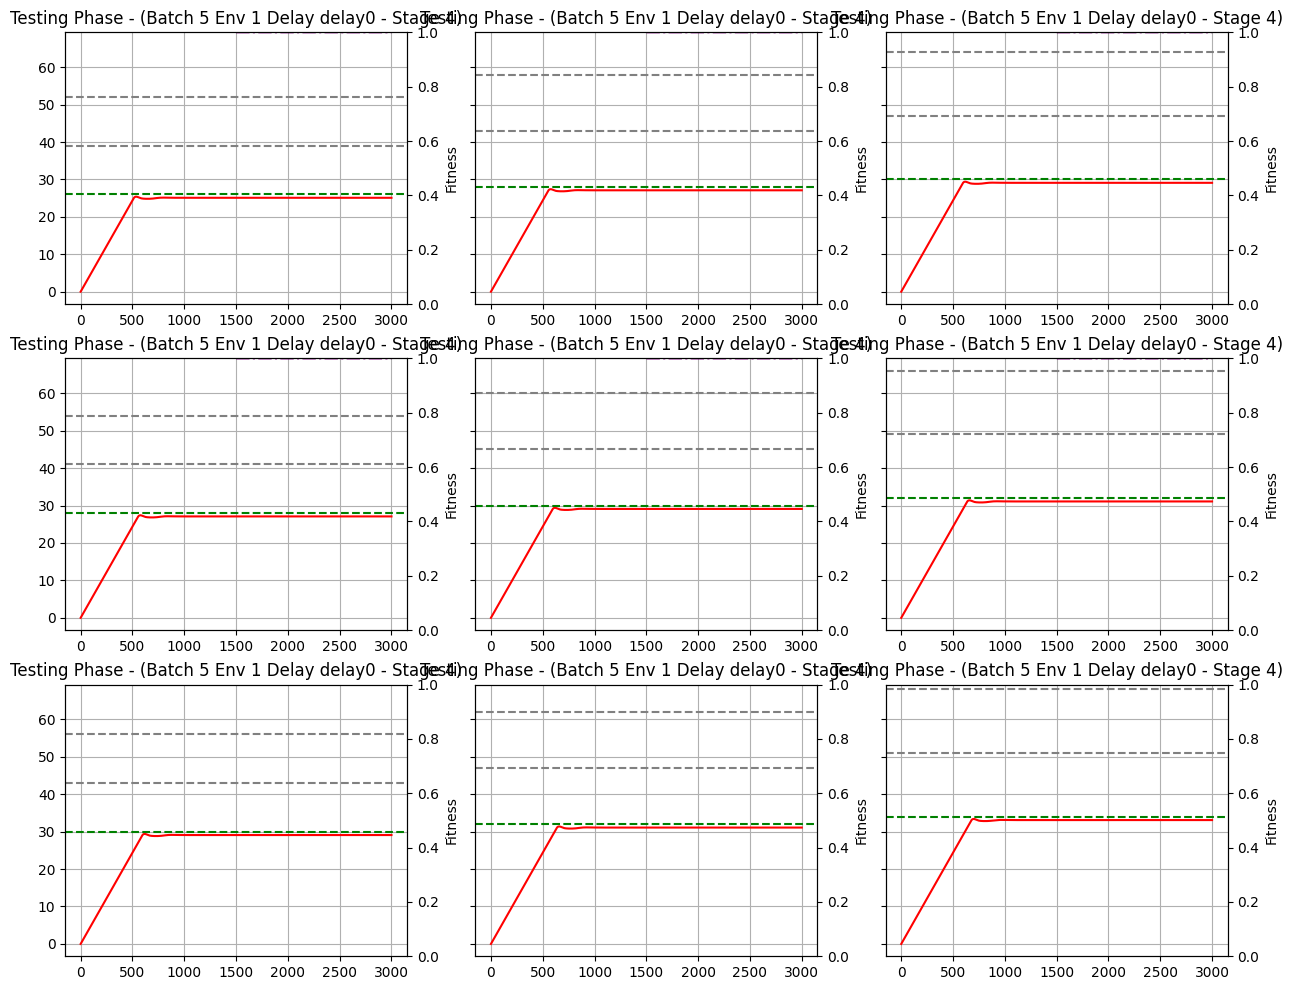

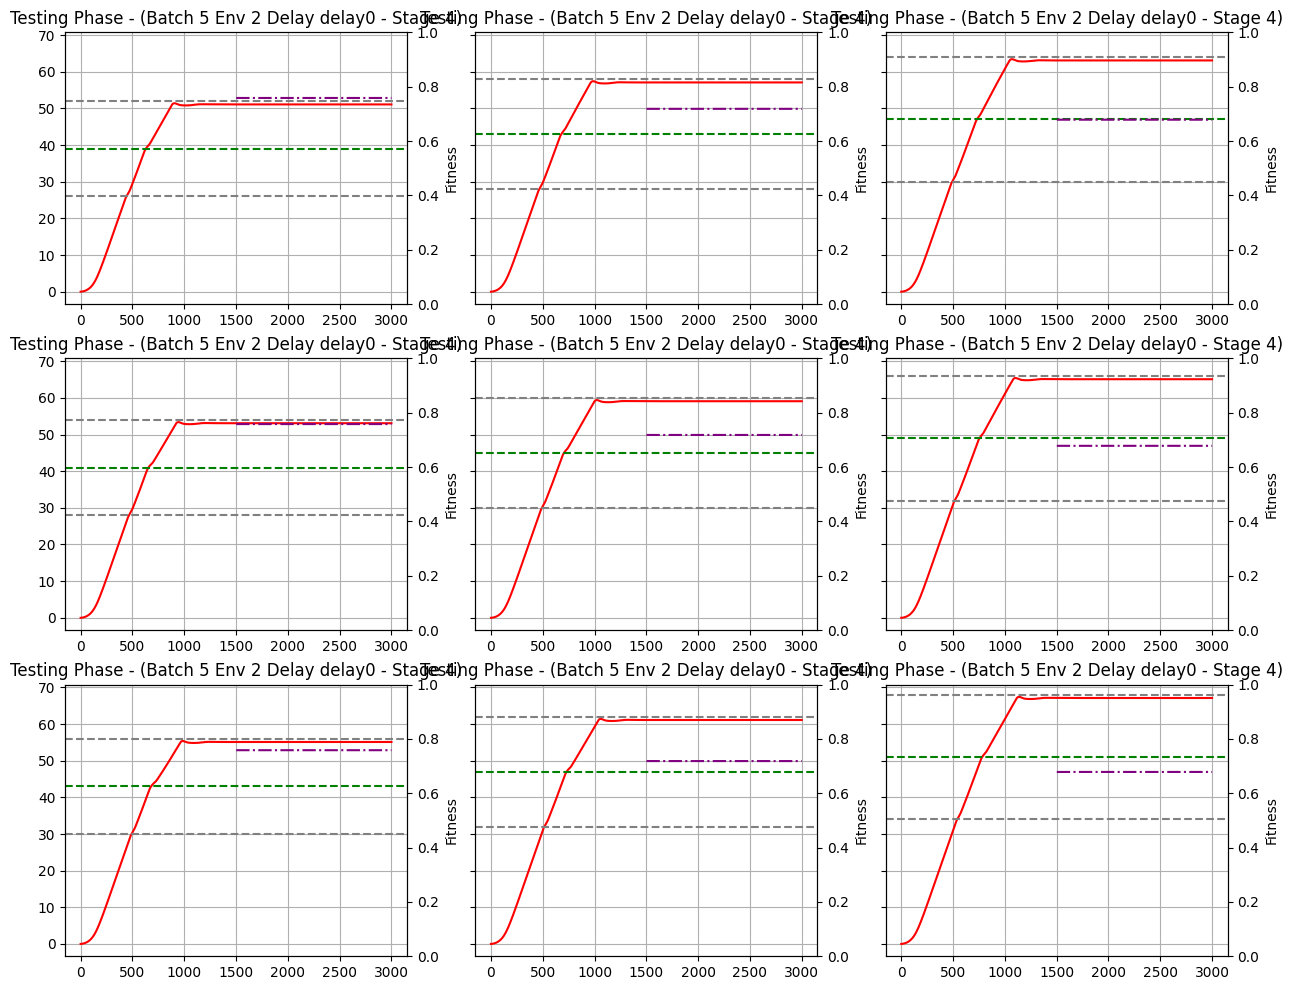

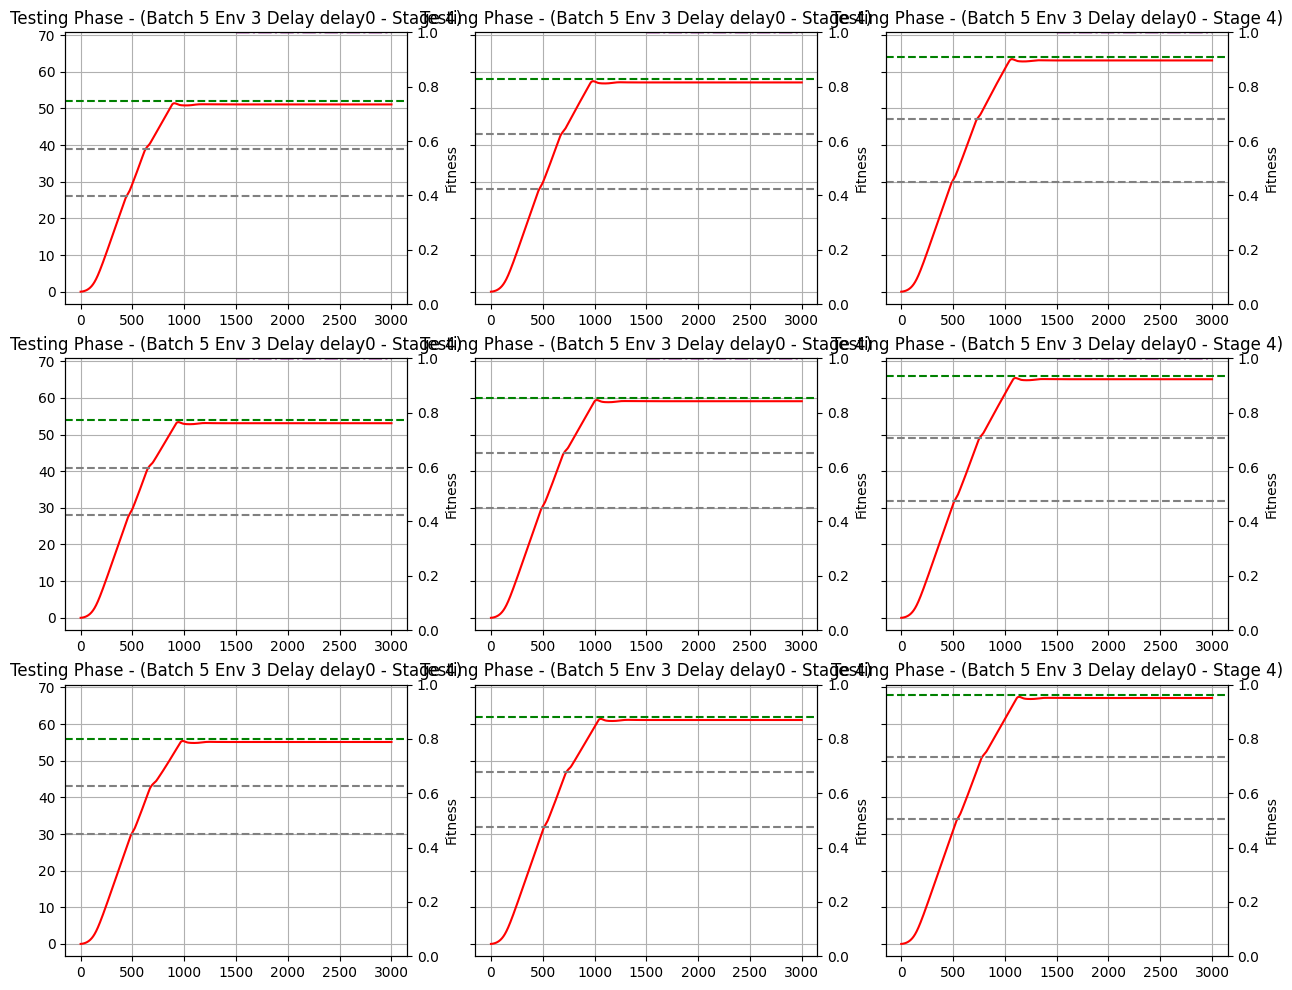

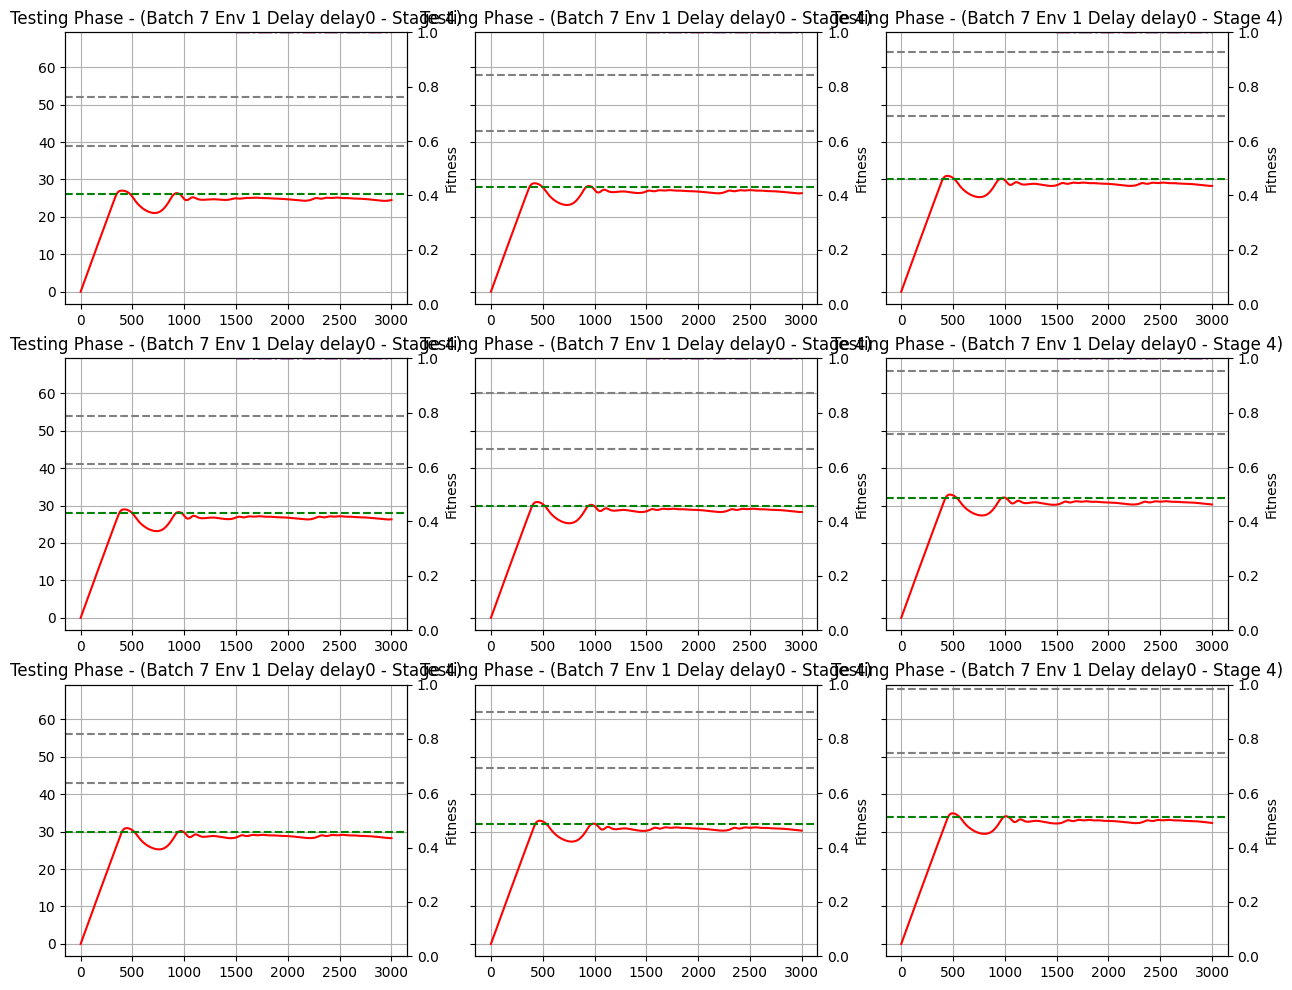

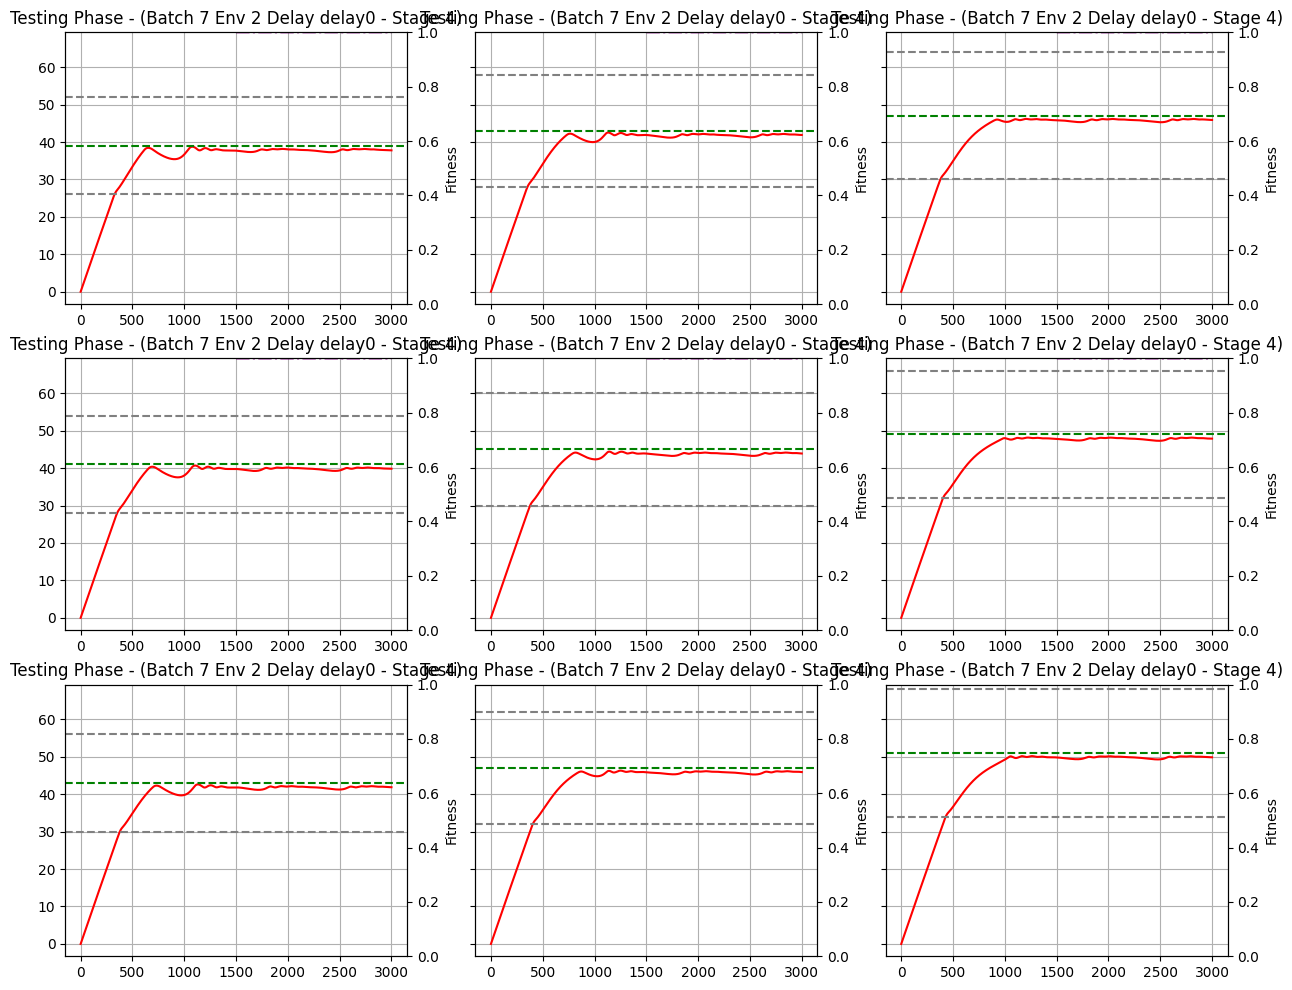

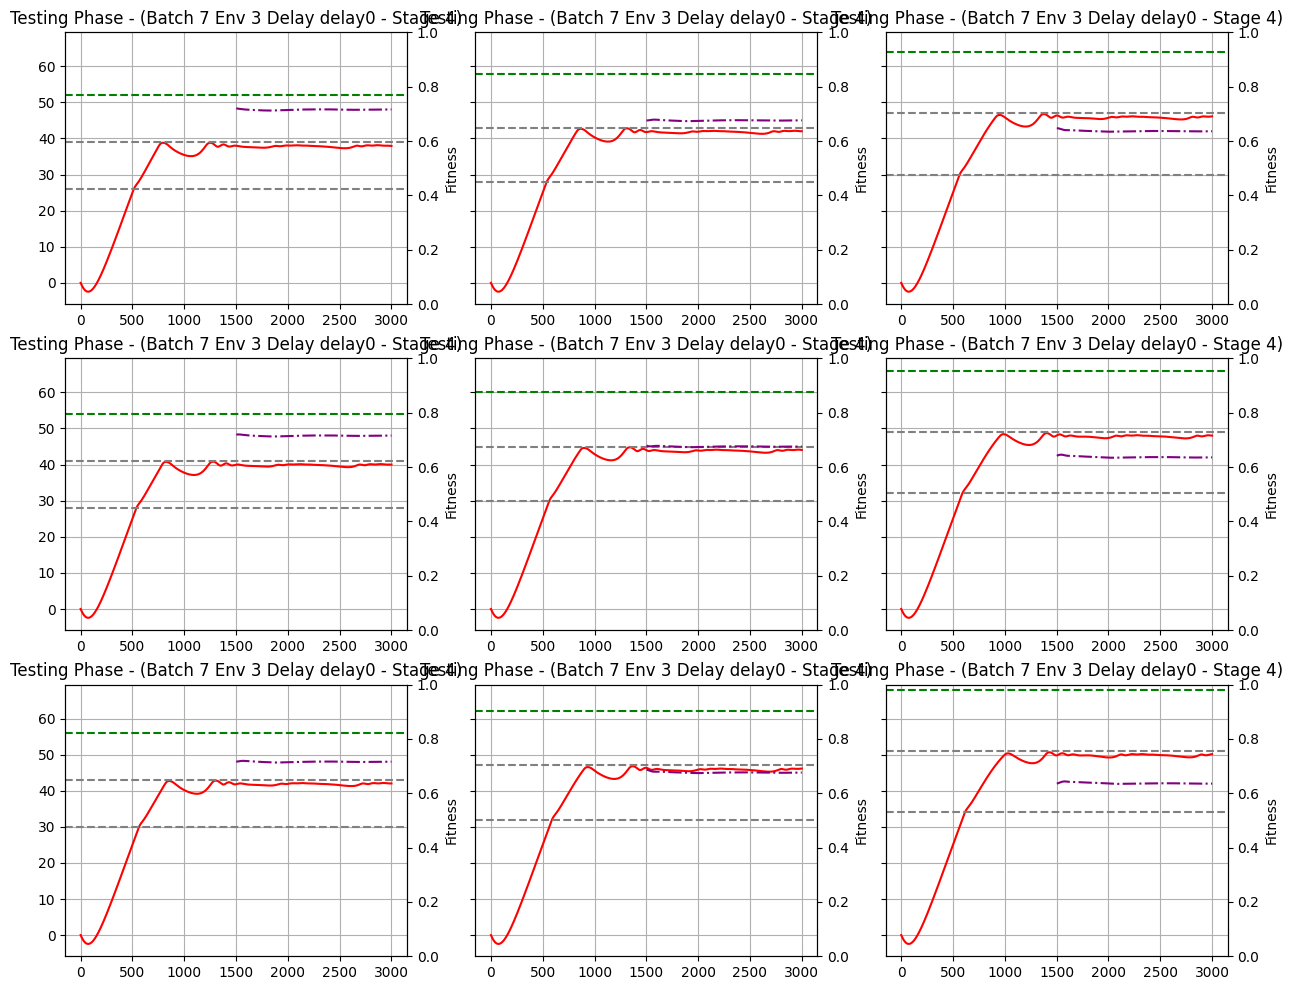

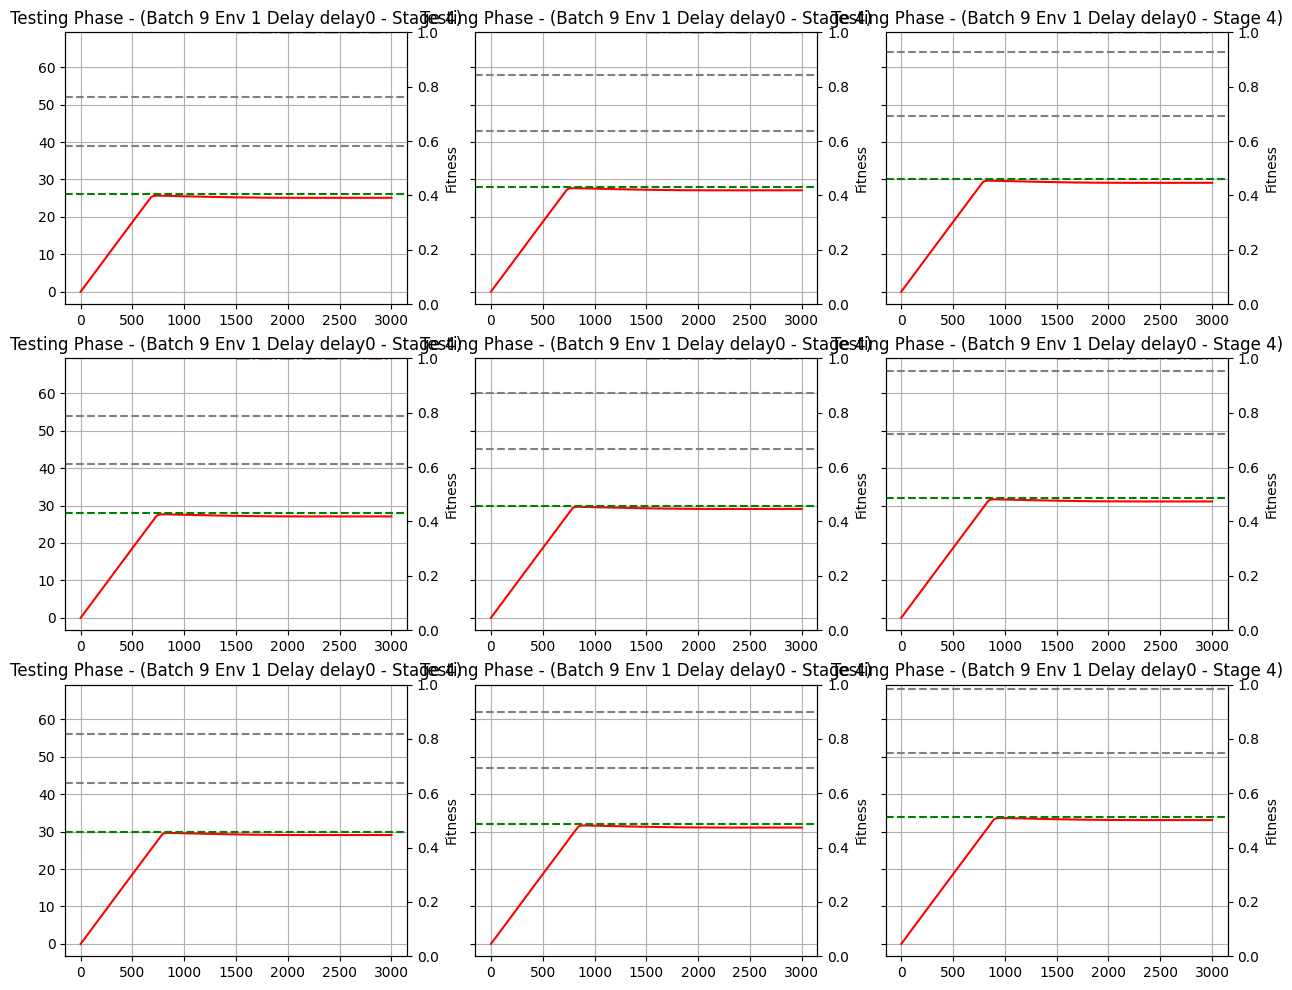

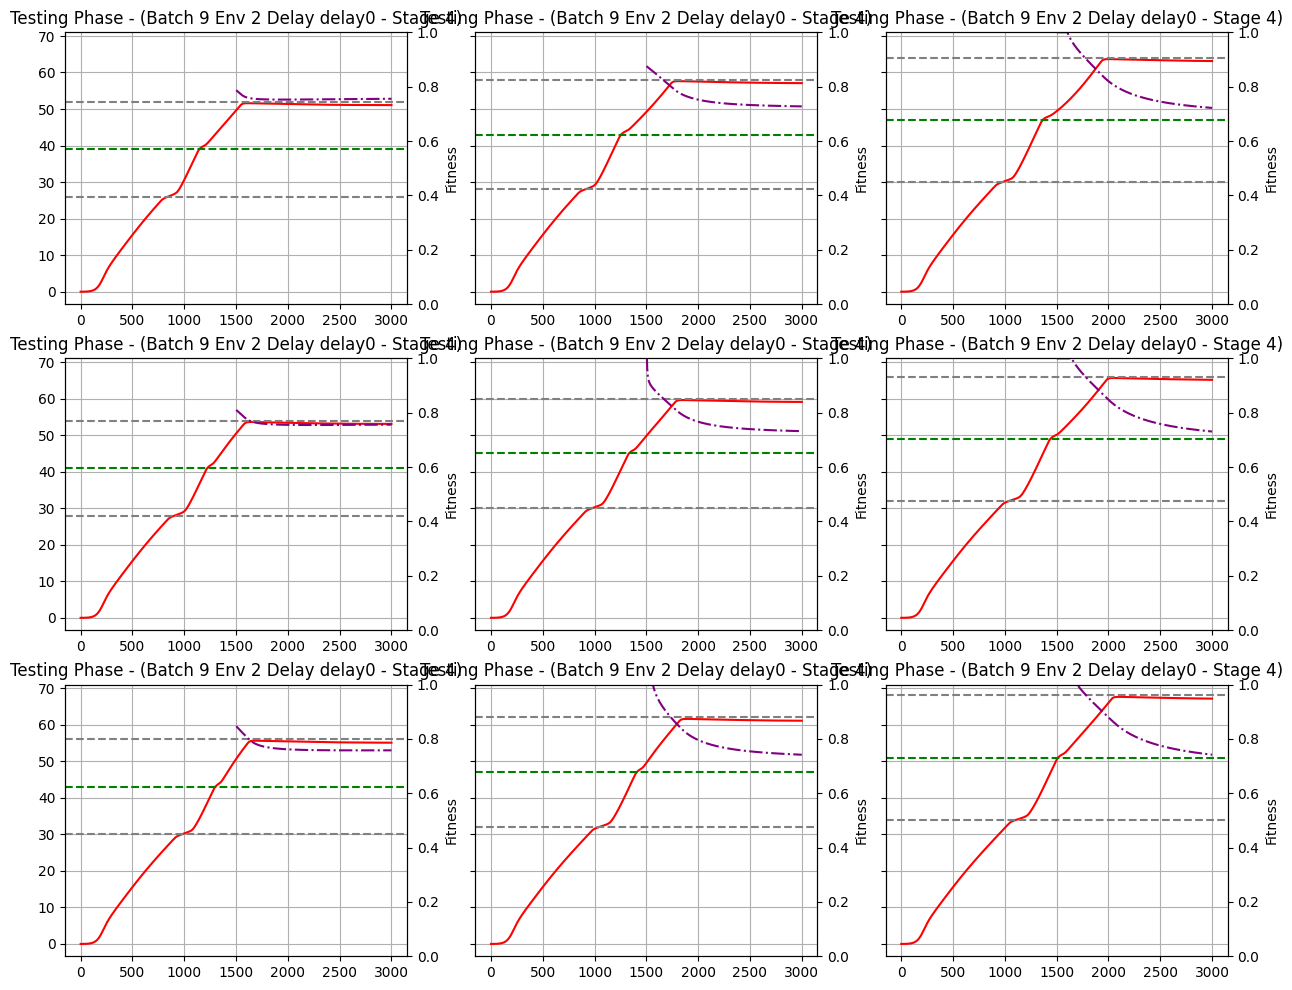

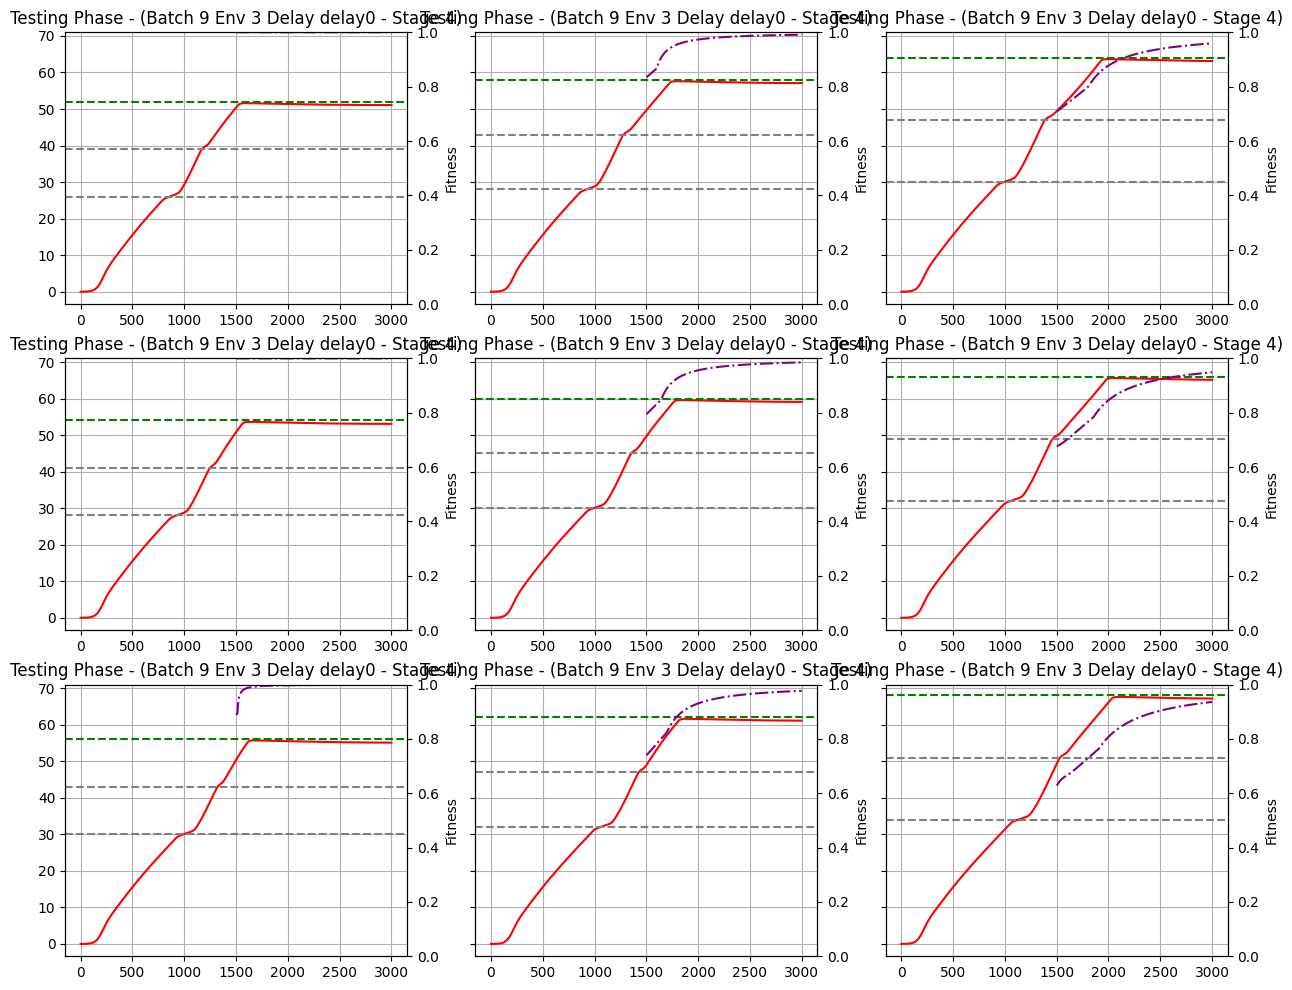

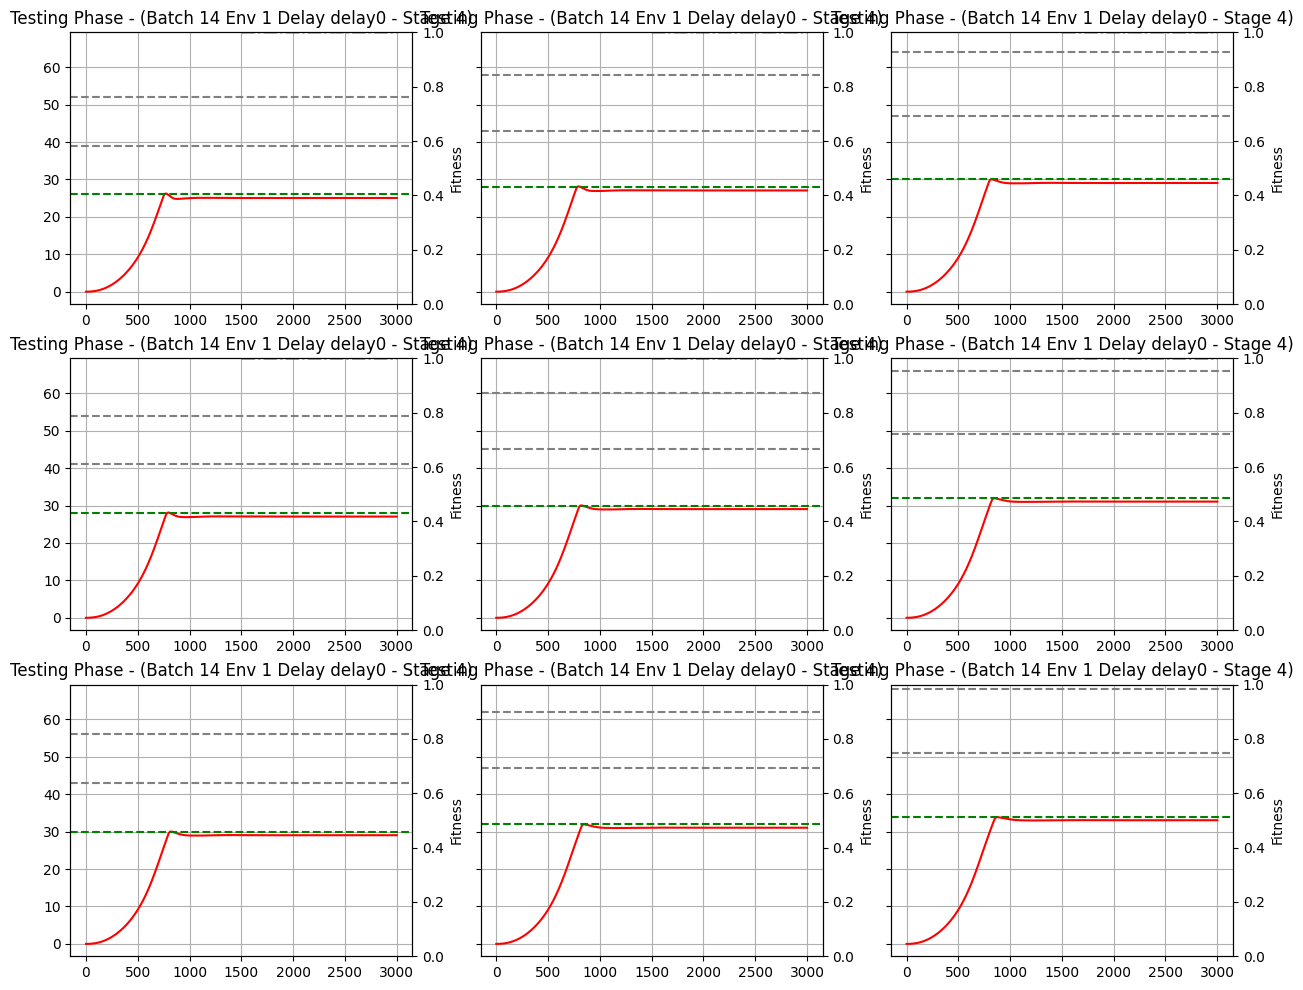

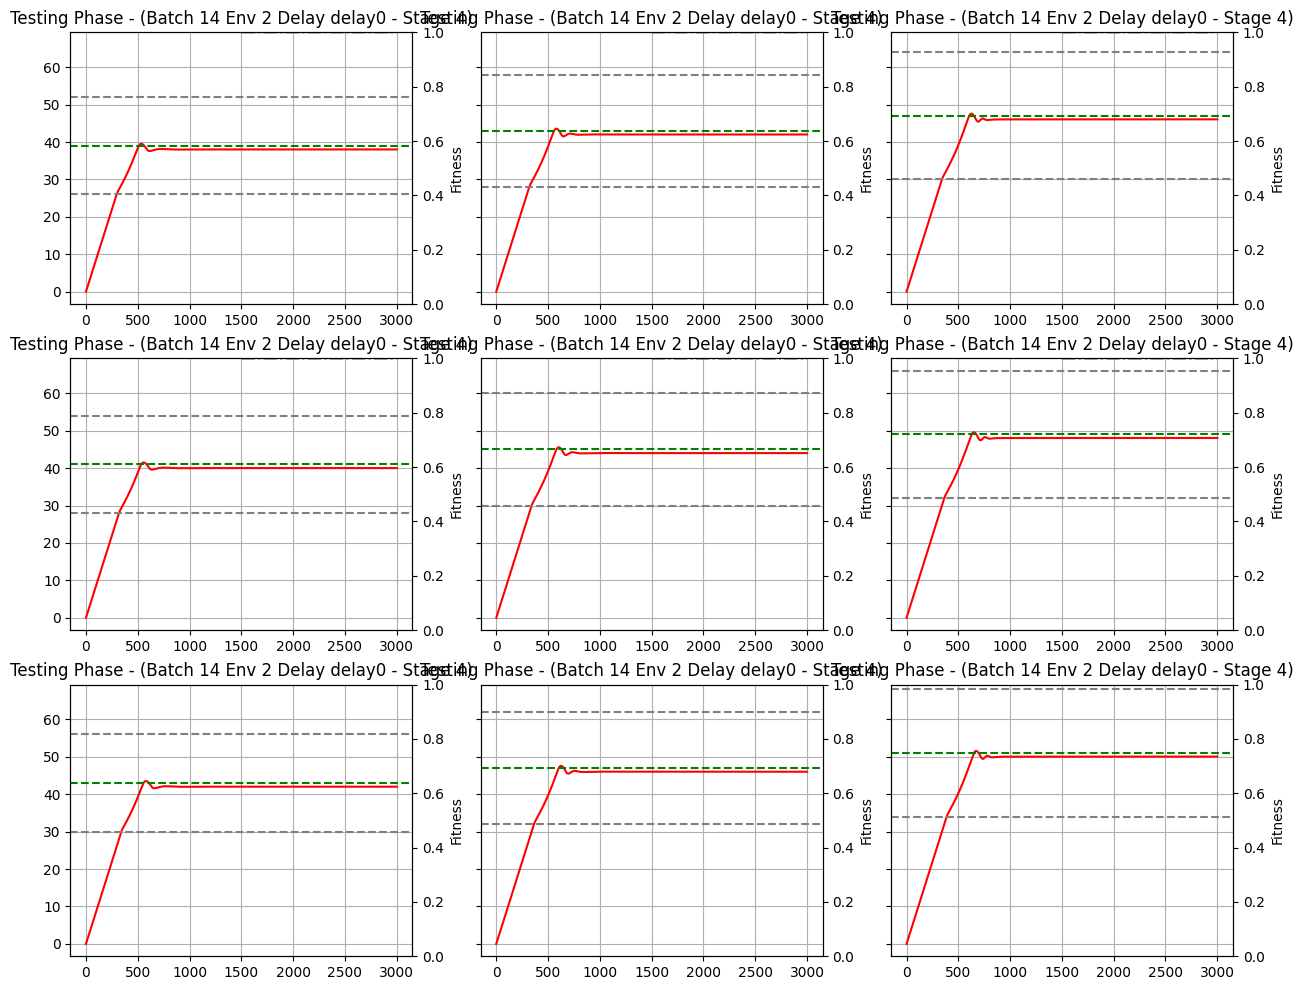

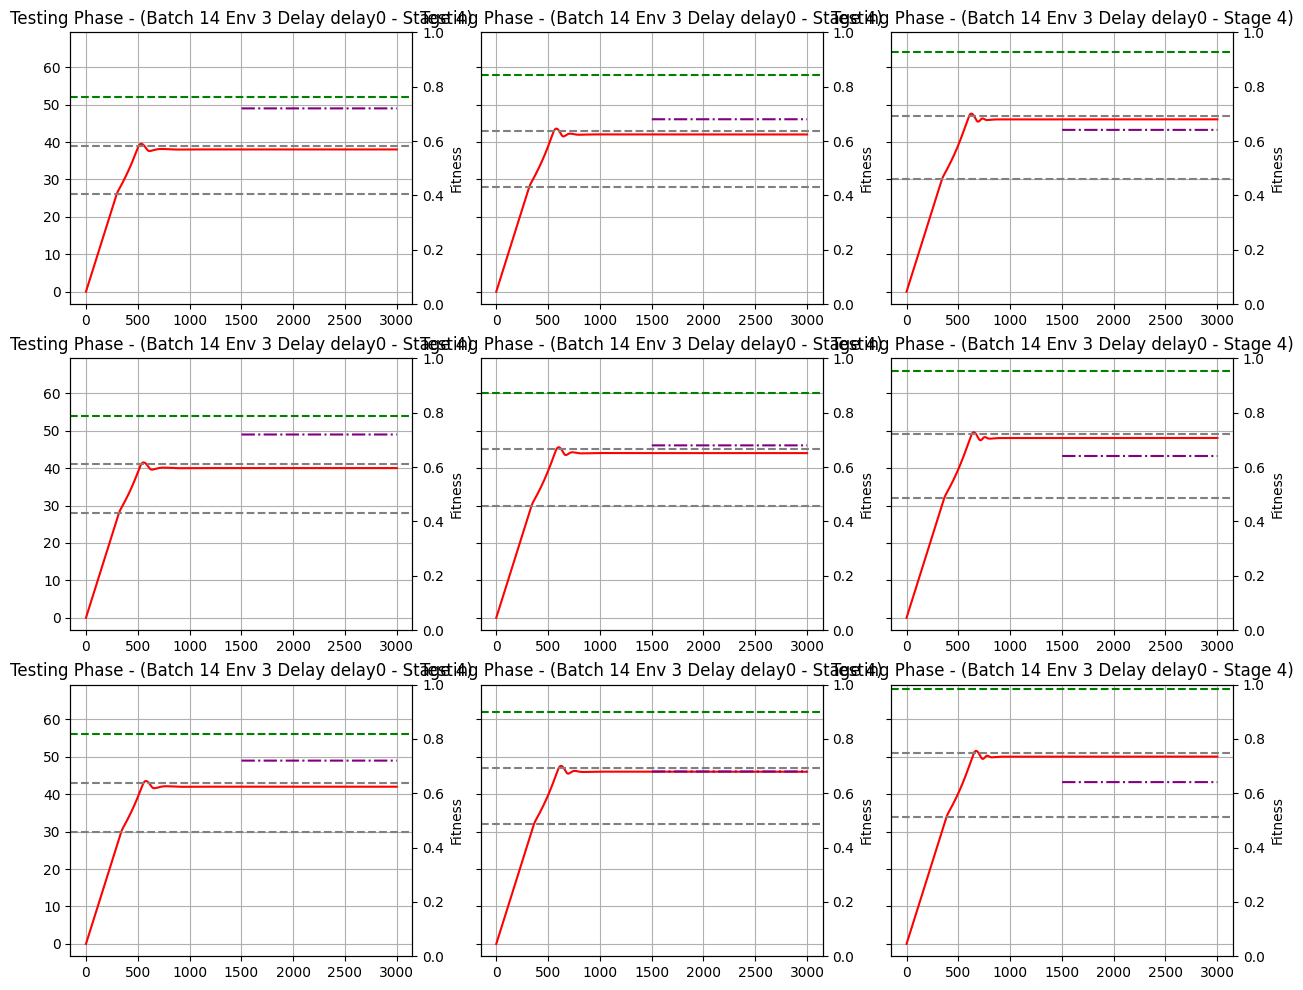

In [7]:
# training phase + pause behaviour
# this is looking at a single file
# phases = ["Phase1", "Phase2"]
phases = ["Phase3"]

delays = ["delay0"]
envs = [1,2,3]

run = 0

for batch_index, batch in enumerate(batches):
    for env in envs:
        # fig, ax = plt.subplots(figsize=(16,10))
        # first plot phase 1 and phase 2 in the same plot
        # phase1_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_Env{env}_{delay}_{stage}_Phase1.dat"
        # phase2_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_Env{env}_{delay}_{stage}_Phase2.dat"
        # combined = []
        # combined.extend(read_ith_line(1, phase1_dir))
        # combined.extend(read_ith_line(1, phase2_dir))
        # x = list(range(0, len(combined)))
        # ax.plot(x, combined, label=f"Agent", color="red")

        # landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_{run}_env{env}_{delay}_{stage}_phase2.dat"
        # landmark = read_ith_line(1, landmark_file)
        # food = landmark[3]
        # landmarks = [0,1,2]
        # for i in landmarks:
        #     if (landmark[i] != food):
        #         ax.axhline(y=landmark[i], linestyle="--", label=f"Landmark {i}", color="grey")
        # ax.axhline(y=food, linestyle="--", label="Food Position", color="green")

        # # plot it
        # ax.set_xlabel("Time")
        # ax.set_ylabel("Distance from origin")
        # ax.set_title(f"Training Phase - (Batch {batch} {env} {delay})")
        # ax.grid(True)
        # fig.show()


        # then plot phase 3 in a 3x3 grid
        fig, axes = plt.subplots(3, 3, figsize=(15,12), sharey=True)

        phase3_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_Env{env}_{delay}_{stage}_Phase3.dat"
        landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_{run}_env{env}_{delay}_{stage}_phase3.dat"
        fitness_file = result_dir+ f"batch_{batch}/run_{run}/fitness_{run}_env{env}_{delay}_{stage}_phase1.dat"

        counter = 1
        for x in range(0, 3):
            for y in range(0,3):
                ax = axes[x, y]
                ax2 = ax.twinx()
                
                # the behaviour
                behaviour = read_ith_line(counter, phase3_dir)
                behaviour_x = list(range(0, len(behaviour)))
                ax.plot(behaviour_x, behaviour, label=f"Agent", color="red")

                # the landmark
                landmark = read_ith_line(counter, landmark_file)
                landmarks = [0,1,2]
                for i in landmarks:
                    if (i !=env-1):
                        ax.axhline(y=landmark[i], linestyle="--", label=f"Landmark {i}", color="grey")
                    else:
                        ax.axhline(y=landmark[i], linestyle="--", label="Food Position", color="green")

                # fitness
                fitness = read_ith_line(counter, fitness_file)
                fitness_start = (len(behaviour) - len(fitness))
                fitness_x = range(fitness_start, len(fitness)+fitness_start)

                ax2.plot(fitness_x, fitness, linestyle="dashdot", color="purple")
                counter += 1

                ax2.set_ylim(bottom=0, top=1)
                ax2.set_ylabel("Fitness")
                ax.grid(True)

                ax.set_title(f"Testing Phase - (Batch {batch} Env {env} Delay {delay} - Stage 4)") 

        plt.show(block=False)